In [1]:
import torch 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import os
outdir = r"C:\Document\Serieux\Travail\python_work\cEBNM_torch\notebooks\cEBMF_test\hierarchical_factor_model"
os.makedirs(outdir, exist_ok=True)
# Reproducibility


In [ ]:
#torch.manual_seed(1)
N = 2000  
P= 200
# Scatter of x vs y 
torch.manual_seed(1)

# -------------------------
# 2) Generate f (3 x 200)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# -------------------------

t0 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t1 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t2 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t11 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t12 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t21 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t22 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1

a0 = t0 * torch.randn(P)
b1 = t1 * torch.randn(P)
b2 = t2 * torch.randn(P)
detla11= t11 *torch.randn(P)

detla12= t11 *torch.randn(P)
detla21= t11 *torch.randn(P)
detla22= t11 *torch.randn(P)  
f_mat = torch.stack([a0,b1,b2, detla11, detla12,detla21, detla22 ], dim=0)
f_mat

tensor([[ 0.0000, -0.0000, -0.3753,  ..., -0.0000,  0.0000,  0.0000],
        [ 0.4997,  0.0000,  0.0000,  ...,  0.0000,  1.0183, -0.9653],
        [-0.0091,  1.0409,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000, -0.0000,  0.0000,  ...,  0.0448, -0.4094, -1.2776],
        [ 0.0000, -0.0000, -0.0000,  ..., -1.8529,  1.8468,  0.8508],
        [-0.0000,  0.0000,  0.0000,  ..., -0.4984,  2.1032, -0.0119]])

In [3]:

N= 1000

L = torch.zeros(N, 7, dtype=torch.float32)


L[:,0]=1
L[0:500, 1]=1

L [500:,2]=1
L[0:250,3]=1
L[251:500,4]=1

L[501:750,5]=1

L[751:,6]=1

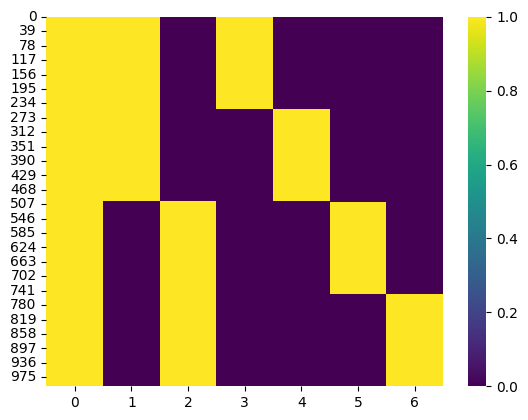

In [4]:


sns.heatmap(L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()


In [5]:
L.shape

torch.Size([1000, 7])

In [6]:
L 

tensor([[1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [1., 0., 1.,  ..., 0., 0., 1.],
        [1., 0., 1.,  ..., 0., 0., 1.],
        [1., 0., 1.,  ..., 0., 0., 1.]])

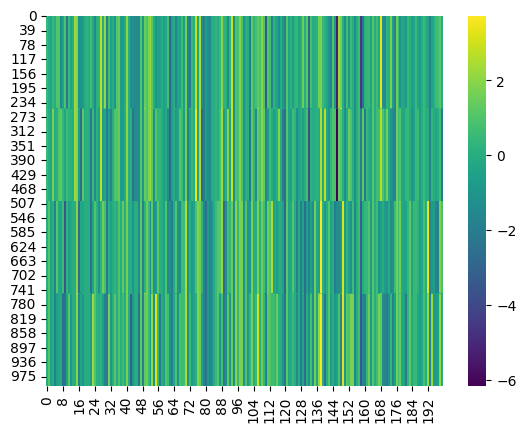

In [7]:
X_true= L@f_mat 
Z = L@f_mat + 0.5*torch.randn(N, P)  * 2.5  # (N, M)
Z_np = Z.detach().cpu().numpy()

# Save as tab-delimited text
np.savetxt(os.path.join(outdir, "Z_matrix.txt"), Z_np, fmt="%.6f", delimiter="\t")

X_true=    L@f_mat 
X_np = X_true.detach().cpu().numpy()

# Save as tab-delimited text
np.savetxt(os.path.join(outdir, "Z_matrix.txt"), Z_np, fmt="%.6f", delimiter="\t")
np.savetxt(os.path.join(outdir, "X_matrix.txt"), X_np, fmt="%.6f", delimiter="\t")
sns.heatmap(X_true , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

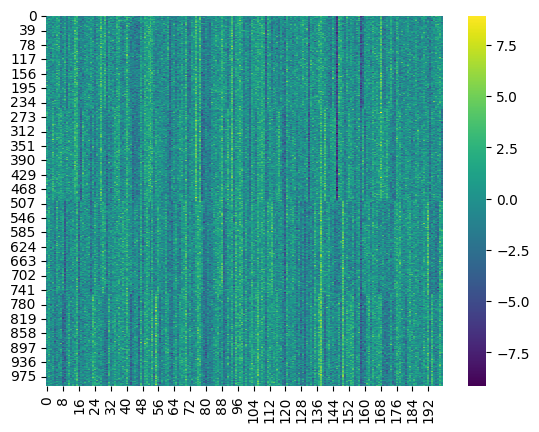

In [8]:
sns.heatmap(Z , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

In [9]:
from cebmf_torch import cEBMF

In [10]:
mycebmf0=  cEBMF(data=Z ,K=10 ) 
mycebmf0.initialise_factors()
mycebmf0.fit(20)

CEBMFResult(L=tensor([[-1.1844e+01, -9.8975e+00, -5.7605e+00,  ...,  1.7304e-33,
          0.0000e+00,  0.0000e+00],
        [-1.5022e+01, -7.8946e+00, -6.6444e+00,  ..., -1.0219e-34,
          0.0000e+00,  0.0000e+00],
        [-1.3277e+01, -9.2566e+00, -6.8217e+00,  ...,  7.9933e-34,
          0.0000e+00,  0.0000e+00],
        ...,
        [-1.4825e+01,  9.1445e+00, -4.2391e+00,  ...,  3.6765e-33,
          0.0000e+00,  0.0000e+00],
        [-1.2584e+01,  1.0627e+01, -2.2236e+00,  ...,  6.5513e-33,
          0.0000e+00,  0.0000e+00],
        [-1.2954e+01,  7.3789e+00, -4.3393e+00,  ..., -1.8235e-33,
          0.0000e+00,  0.0000e+00]]), F=tensor([[-0.0164, -0.0356,  0.0003,  ...,  0.0000,  0.0000,  0.0000],
        [-0.0377,  0.0675,  0.0002,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0265, -0.0009,  0.0060,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0251, -0.0869, -0.0905,  ...,  0.0000,  0.0000,  0.0000],
        [-0.1024,  0.0585, -0.0357,  ...,  0.0000,  0.0000

In [11]:
mycebmf01=  cEBMF(data=Z, 
                 prior_L="gbinary", K=10,
                  allow_backfitting=False ) 
mycebmf01.initialise_factors()
  
mycebmf01.fit(20)

CEBMFResult(L=tensor([[5.8365e-05, 2.1049e-16, 7.1973e-11,  ..., 2.5444e-06, 5.7041e-01,
         2.6018e-06],
        [6.3114e-05, 1.5529e-10, 1.3677e-11,  ..., 2.5445e-06, 5.6914e-01,
         2.6018e-06],
        [6.0486e-05, 2.7994e-14, 4.7054e-12,  ..., 2.5444e-06, 5.6364e-01,
         2.6018e-06],
        ...,
        [5.5609e-05, 9.0657e+00, 2.5868e-10,  ..., 2.5444e-06, 5.5118e-01,
         2.6018e-06],
        [1.0930e-13, 9.3385e+00, 3.9997e-07,  ..., 2.5444e-06, 5.7196e-01,
         2.6018e-06],
        [8.1555e-11, 8.5637e+00, 1.4221e-10,  ..., 2.5444e-06, 5.4027e-01,
         2.6018e-06]]), F=tensor([[ 5.4814e+03, -1.9462e-02,  3.8535e-03,  ..., -1.1217e-01,
         -1.1269e-04, -1.1037e-01],
        [-8.9972e+01,  1.2442e-01,  3.8290e-05,  ..., -6.1256e-02,
         -4.7968e-05, -6.0485e-02],
        [-1.7729e+03, -3.2618e-02,  6.1951e-04,  ..., -4.7407e-02,
         -3.7796e-05, -4.6790e-02],
        ...,
        [ 8.4335e+03, -9.4643e-02, -1.3907e-01,  ...,  1.3543e-01

In [12]:
 
mycebmf2=  cEBMF(data=Z,self_row_cov=True,
                 prior_L="cgb_sharp", K=10,
                  allow_backfitting=False ) 
mycebmf2.initialise_factors()
 
mycebmf2.fit(50)

[CGB] Epoch 10/10, Loss=43.6305, mu2=-0.080, sigma2=0.993
[CGB] Epoch 10/10, Loss=22.0734, mu2=-0.005, sigma2=0.587
[CGB] Epoch 10/10, Loss=11.4824, mu2=0.020, sigma2=0.403
[CGB] Epoch 10/10, Loss=9.1750, mu2=0.050, sigma2=0.343
[CGB] Epoch 10/10, Loss=2.2096, mu2=-0.002, sigma2=0.092
[CGB] Epoch 10/10, Loss=2.1964, mu2=0.002, sigma2=0.074
[CGB] Epoch 10/10, Loss=2.1777, mu2=0.008, sigma2=0.069
[CGB] Epoch 10/10, Loss=2.1641, mu2=0.002, sigma2=0.086
[CGB] Epoch 10/10, Loss=2.1678, mu2=0.001, sigma2=0.111
[CGB] Epoch 10/10, Loss=2.1542, mu2=0.000, sigma2=0.120
[CGB] Epoch 10/10, Loss=37.2907, mu2=-0.160, sigma2=0.409
[CGB] Epoch 10/10, Loss=17.6127, mu2=-0.011, sigma2=0.124
[CGB] Epoch 10/10, Loss=7.2195, mu2=0.111, sigma2=0.052
[CGB] Epoch 10/10, Loss=4.8952, mu2=0.135, sigma2=0.040
[CGB] Epoch 10/10, Loss=2.3546, mu2=-0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=1.9847, mu2=0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=1.8249, mu2=-0.003, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.1631, mu2=

CEBMFResult(L=tensor([[-0.4682, -0.2057,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.4682, -0.2057,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.4682, -0.2057,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [-0.4682,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.4682,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.4682,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]), F=tensor([[ 1.5647e-02, -2.6060e+00, -5.6533e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-2.3560e+00,  5.5995e+00,  2.2731e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 7.9708e-01, -2.6831e-02,  3.3485e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [ 9.0890e-01, -7.2254e+00, -4.3555e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-4.3720e+00,  4.8212e+00, -1.2773e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-4.4032e-03,

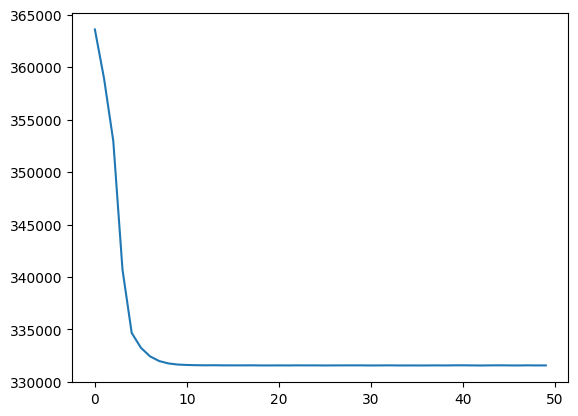

In [13]:
plt.plot(mycebmf2.obj)

In [14]:
k=0
#mycebmf2._update_factors(k)

In [15]:
 
mycebmf21=  cEBMF(data=Z,self_row_cov=True,
                 prior_L="cgb_sharp_2", K=10,
                  allow_backfitting=False) 
mycebmf21.initialise_factors()
 
  
mycebmf21.fit(50)

[CGB-2] Epoch 10/10, Loss=25.2003, mu_pos=0.655, mu_neg=-0.733, sigma1=1.880, sigma2=1.616
[CGB-2] Epoch 10/10, Loss=15.5004, mu_pos=0.734, mu_neg=-0.734, sigma1=0.961, sigma2=0.965
[CGB-2] Epoch 10/10, Loss=9.1070, mu_pos=0.734, mu_neg=-0.734, sigma1=0.597, sigma2=0.568
[CGB-2] Epoch 10/10, Loss=7.5906, mu_pos=0.734, mu_neg=-0.734, sigma1=0.511, sigma2=0.467
[CGB-2] Epoch 10/10, Loss=2.2126, mu_pos=0.721, mu_neg=-0.720, sigma1=0.214, sigma2=0.266
[CGB-2] Epoch 10/10, Loss=2.2111, mu_pos=0.725, mu_neg=-0.722, sigma1=0.232, sigma2=0.294
[CGB-2] Epoch 10/10, Loss=2.1839, mu_pos=0.718, mu_neg=-0.719, sigma1=0.347, sigma2=0.101
[CGB-2] Epoch 10/10, Loss=2.1649, mu_pos=0.723, mu_neg=-0.723, sigma1=0.226, sigma2=0.166
[CGB-2] Epoch 10/10, Loss=2.1613, mu_pos=0.721, mu_neg=-0.724, sigma1=0.178, sigma2=0.192
[CGB-2] Epoch 10/10, Loss=2.1549, mu_pos=0.722, mu_neg=-0.719, sigma1=0.299, sigma2=0.194
[CGB-2] Epoch 10/10, Loss=23.4713, mu_pos=0.618, mu_neg=-0.775, sigma1=1.348, sigma2=1.078
[CGB-2]

CEBMFResult(L=tensor([[-1.0723, -0.8274, -0.6763,  ...,  0.0000,  0.0000,  0.0000],
        [-1.0724, -0.8274, -0.6764,  ...,  0.0000,  0.0000,  0.0000],
        [-1.0723, -0.8274, -0.6764,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [-1.0724,  0.9023, -0.6763,  ...,  0.0000,  0.0000,  0.0000],
        [-1.0723,  0.9024, -0.6278,  ...,  0.0000,  0.0000,  0.0000],
        [-1.0723,  0.9021, -0.6762,  ...,  0.0000,  0.0000,  0.0000]]), F=tensor([[-2.2200e-01, -3.4680e-01,  7.0790e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-4.6921e-01,  6.6740e-01,  9.5170e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 3.4687e-01, -1.0293e-02,  3.7468e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [ 6.1205e-02, -8.5790e-01, -6.1099e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.3190e+00,  5.7458e-01, -1.6471e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 7.0789e-01,

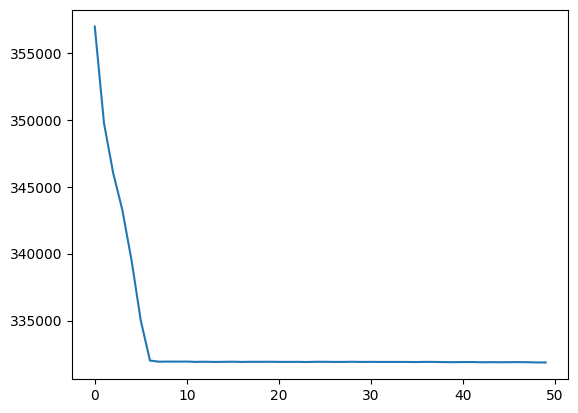

In [16]:
plt.plot(mycebmf21.obj)

In [17]:
 
mycebmf1=  cEBMF(data=Z,self_row_cov=True,
                 prior_L="cgb", K=10,
                  allow_backfitting=False ) 
mycebmf1.initialise_factors()
 
  
mycebmf1.fit(20)

[CGB] Epoch 10/10, Loss=5.0280, mu2=-0.080, sigma2=14.122
[CGB] Epoch 10/10, Loss=4.5064, mu2=-0.006, sigma2=8.342
[CGB] Epoch 10/10, Loss=4.0589, mu2=0.009, sigma2=5.480
[CGB] Epoch 10/10, Loss=3.8826, mu2=0.038, sigma2=4.820
[CGB] Epoch 10/10, Loss=2.1348, mu2=-0.010, sigma2=2.854
[CGB] Epoch 10/10, Loss=2.1274, mu2=-0.002, sigma2=2.974
[CGB] Epoch 10/10, Loss=2.1076, mu2=0.010, sigma2=2.994
[CGB] Epoch 10/10, Loss=2.0954, mu2=0.008, sigma2=2.775
[CGB] Epoch 10/10, Loss=2.0957, mu2=-0.001, sigma2=2.941
[CGB] Epoch 10/10, Loss=2.0859, mu2=-0.004, sigma2=2.860
[CGB] Epoch 10/10, Loss=5.0193, mu2=-0.160, sigma2=14.039
[CGB] Epoch 10/10, Loss=4.5052, mu2=-0.007, sigma2=8.335
[CGB] Epoch 10/10, Loss=4.0481, mu2=0.025, sigma2=5.484
[CGB] Epoch 10/10, Loss=3.8612, mu2=0.074, sigma2=4.849
[CGB] Epoch 10/10, Loss=1.9427, mu2=-0.009, sigma2=3.821
[CGB] Epoch 10/10, Loss=1.9346, mu2=0.027, sigma2=3.936
[CGB] Epoch 10/10, Loss=1.9186, mu2=0.026, sigma2=3.834
[CGB] Epoch 10/10, Loss=1.9118, mu2=0

CEBMFResult(L=tensor([[-12.2373,  -9.4226,  -7.2850,  ...,   0.0000,   0.0000,   0.0000],
        [-15.5118,  -7.4919,  -8.3321,  ...,   0.0000,   0.0000,   0.0000],
        [-13.6852,  -8.7958,  -8.8085,  ...,   0.0000,   0.0000,   0.0000],
        ...,
        [-15.1797,   8.6602,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [-12.9759,  10.0719,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [-13.2458,   6.9624,   0.0000,  ...,   0.0000,   0.0000,   0.0000]]), F=tensor([[-1.6372e-02, -3.6170e-02,  5.5538e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-3.6911e-02,  7.0055e-02,  5.1412e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.5964e-02, -9.2719e-04,  1.4302e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [ 2.3532e-02, -8.8808e-02, -3.7194e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.0040e-01,  6.0875e-02, -3.2374e-02,  ...,  0.0000e+00,
          0.0000e+00,

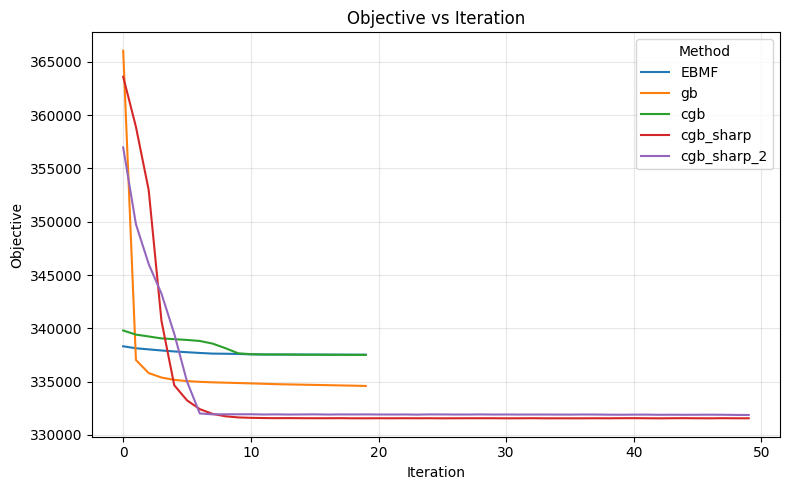

In [18]:
import matplotlib.pyplot as plt
def to1d(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().flatten().numpy()
    return np.asarray(a).ravel()

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(to1d(mycebmf0.obj), label="EBMF")
ax.plot(to1d(mycebmf01.obj), label="gb")
ax.plot(to1d(mycebmf1.obj), label="cgb")
ax.plot(to1d(mycebmf2.obj),  label="cgb_sharp")

ax.plot(to1d(mycebmf21.obj),  label="cgb_sharp_2")

ax.set_title("Objective vs Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
ax.legend(title="Method", loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
mycebmf1.F

tensor([[-1.6372e-02, -3.6170e-02,  5.5538e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-3.6911e-02,  7.0055e-02,  5.1412e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.5964e-02, -9.2719e-04,  1.4302e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [ 2.3532e-02, -8.8808e-02, -3.7194e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.0040e-01,  6.0875e-02, -3.2374e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.2176e-02,  8.8054e-02, -1.4503e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])

(array([ 41., 154.,  48.,   6., 500.,   0.,  13., 102., 122.,  14.]),
 array([-9.5061636 , -7.47693968, -5.44771576, -3.41849184, -1.38926792,
         0.63995647,  2.66917992,  4.69840336,  6.72762775,  8.75685215,
        10.7860775 ]),
 <BarContainer object of 10 artists>)

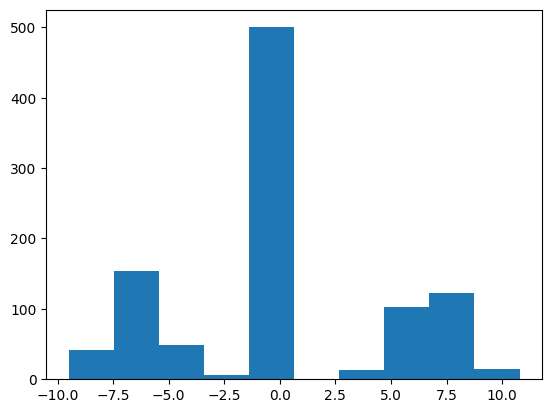

In [20]:
plt.hist(mycebmf1.L[:,3 ])


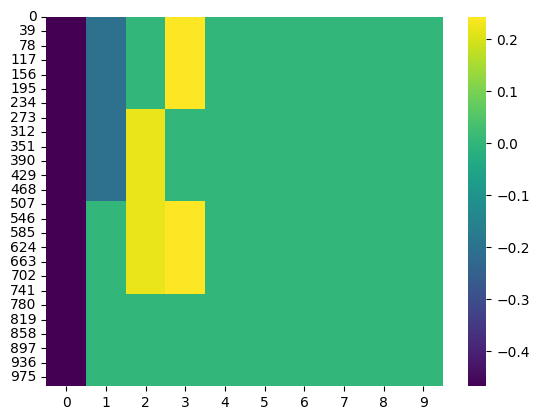

In [21]:
sns.heatmap(mycebmf2.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

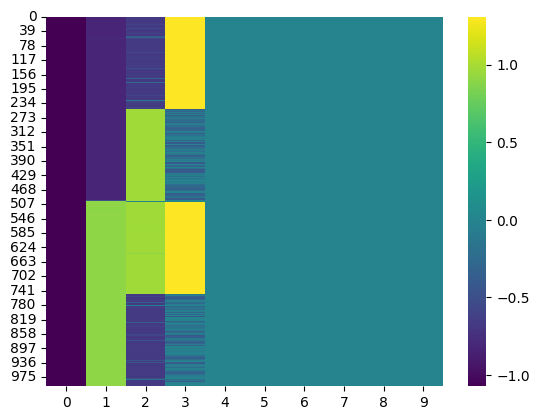

In [34]:
 
sns.heatmap(mycebmf21.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

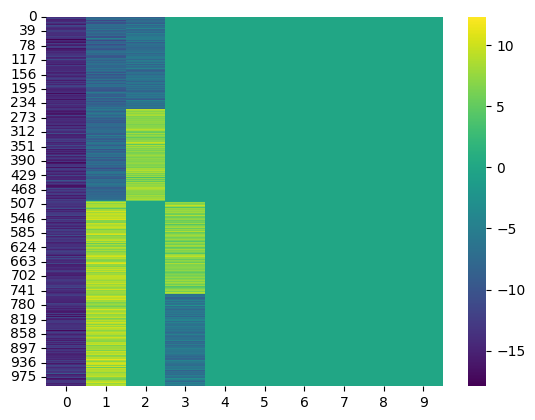

In [23]:
 
sns.heatmap(mycebmf1.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

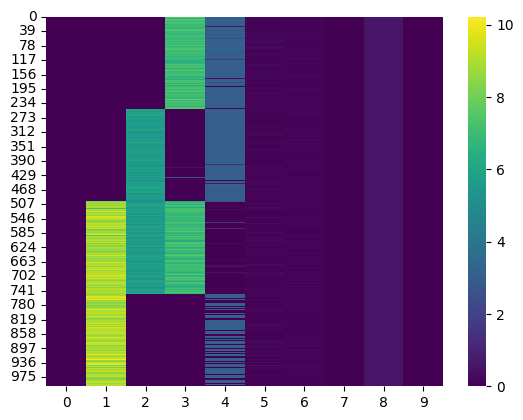

In [24]:
sns.heatmap(mycebmf01.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

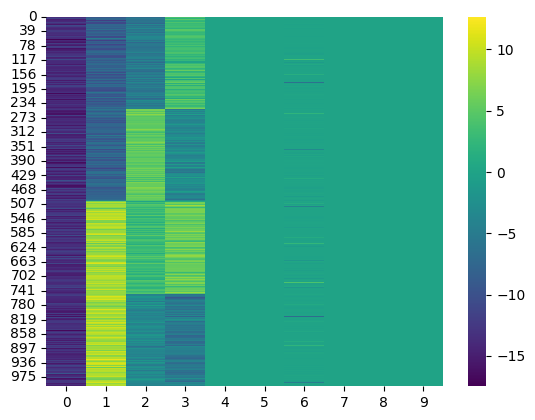

In [25]:
sns.heatmap(mycebmf0.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

In [26]:
mycebmf1.L[:,4]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

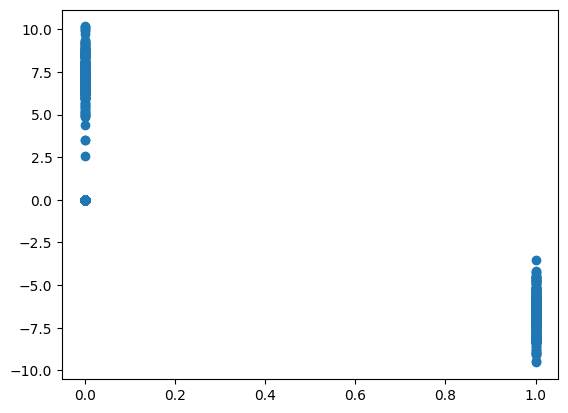

In [27]:
plt.scatter(L[:,3],mycebmf1.L[:,2])

(array([ 41., 154.,  48.,   6., 500.,   0.,  13., 102., 122.,  14.]),
 array([-9.5061636 , -7.47693968, -5.44771576, -3.41849184, -1.38926792,
         0.63995647,  2.66917992,  4.69840336,  6.72762775,  8.75685215,
        10.7860775 ]),
 <BarContainer object of 10 artists>)

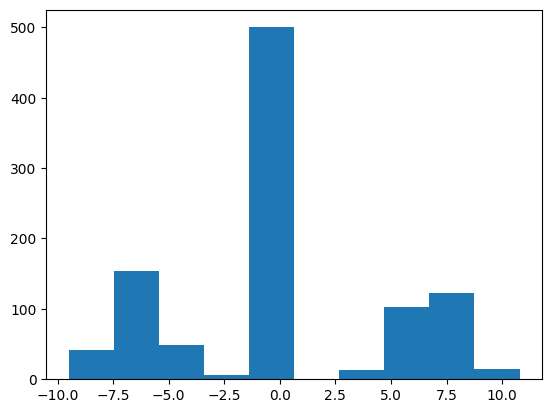

In [28]:
plt.hist(mycebmf1.L[:,3 ])

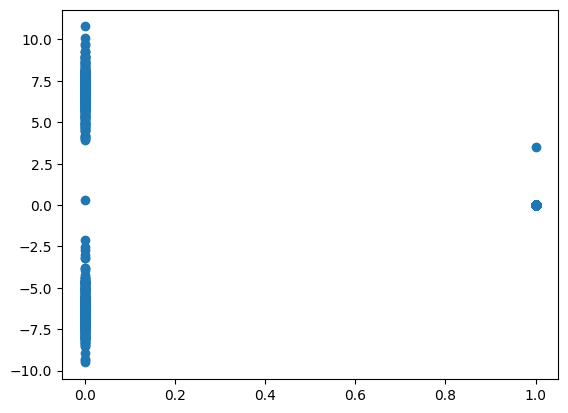

In [29]:
plt.scatter(L[:,1],mycebmf1.L[:,3])

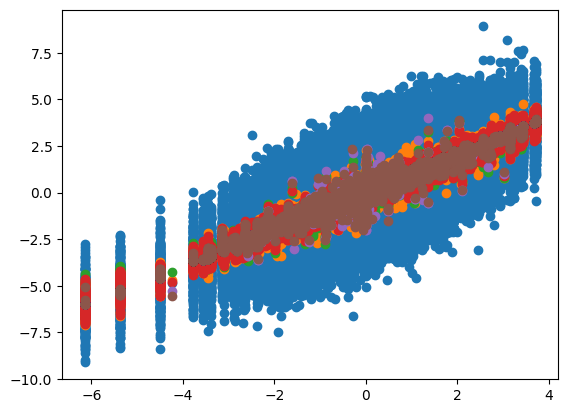

In [30]:
plt.scatter(L@f_mat,Z)
plt.scatter(L@f_mat,mycebmf0.L@mycebmf0.F.T )


plt.scatter(L@f_mat,mycebmf01.L@mycebmf01.F.T )

plt.scatter(L@f_mat,mycebmf1.L@mycebmf1.F.T )
plt.scatter(L@f_mat,mycebmf2.L@ mycebmf2.F.T )

plt.scatter(L@f_mat,mycebmf21.L@ mycebmf21.F.T ) 

In [31]:
print(torch.mean( (L@f_mat - mycebmf0.L@ mycebmf0.F.T )**2))
print(torch.mean((L@f_mat - mycebmf1.L@ mycebmf1.F.T )**2))
print(torch.mean((L@f_mat - mycebmf2.L@ mycebmf2.F.T )**2)) 
 
print(torch.mean((L@f_mat - mycebmf21.L@ mycebmf21.F.T )**2)) 
print(torch.mean((L@f_mat - mycebmf01.L@ mycebmf01.F.T )**2))

tensor(0.0367)
tensor(0.0279)
tensor(0.0057)
tensor(0.0086)
tensor(0.0161)


In [32]:
print(torch.mean( (L@f_mat - mycebmf0.L@ mycebmf0.F.T )**2))
print(torch.mean((L@f_mat - mycebmf1.L@ mycebmf1.F.T )**2))
print(torch.mean((L@f_mat - mycebmf2.L@ mycebmf2.F.T )**2)) 

print(torch.mean((L@f_mat - mycebmf01.L@ mycebmf01.F.T )**2))

tensor(0.0367)
tensor(0.0279)
tensor(0.0057)
tensor(0.0161)


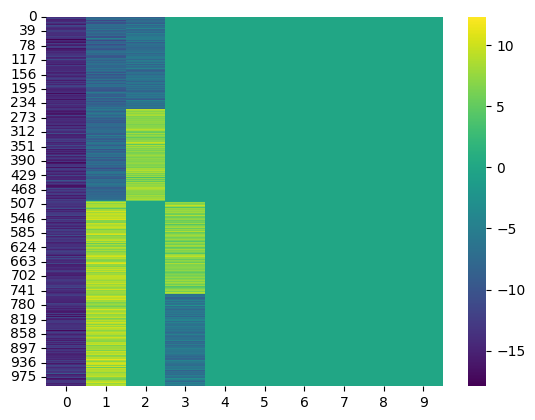

In [33]:
sns.heatmap(mycebmf1.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()